In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [30]:
df=pd.read_csv('placement.csv')

In [31]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Placement')

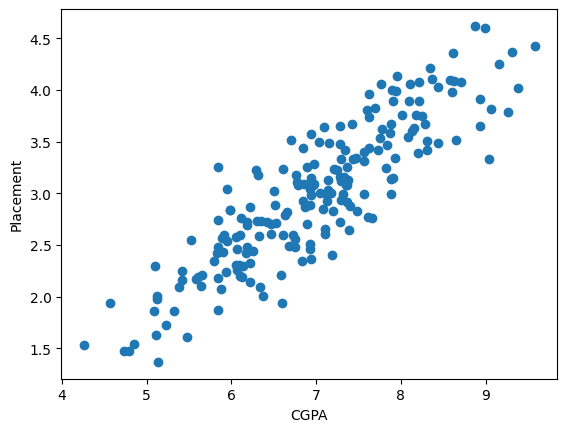

In [32]:
##scatter plot
plt.scatter(df['cgpa'],df['package'])
plt.xlabel("CGPA")
plt.ylabel("Placement")

In [33]:
## Correlation
df.corr()

,cgpa,package
cgpa,1.000000,0.880692
package,0.880692,1.000000


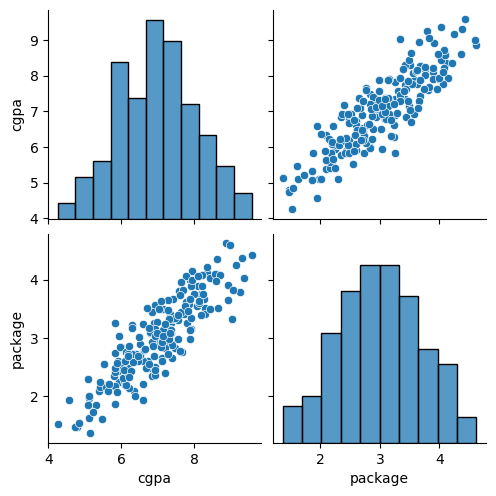

In [34]:
## Seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [35]:
## Independent and dependent features
X=df[['cgpa']] ### independent features should be data frame or 2 dimesnionalarray
y=df['package'] ## this variiable can be in series or 1d array


In [36]:
X_series=df['cgpa']
np.array(X_series).shape

(200,)

In [37]:
np.array(y).shape

(200,)

In [38]:
## Train Test Split
from sklearn.model_selection import train_test_split


In [39]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [40]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [41]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [42]:
X_test=scaler.transform(X_test)

In [43]:
X_test

array([[-0.35367674],
       [ 0.21657182],
       [ 0.31774495],
       [-0.97911063],
       [ 0.84200571],
       [ 1.22830312],
       [ 0.2625596 ],
       [-0.73077659],
       [ 0.28095472],
       [ 0.78682037],
       [-1.75170545],
       [-1.04349354],
       [ 1.09953732],
       [-0.39046697],
       [ 0.7592277 ],
       [ 0.0694109 ],
       [-1.08028376],
       [ 0.3269425 ],
       [-1.31942025],
       [ 0.50169609],
       [-0.8779375 ],
       [-0.16052803],
       [ 0.51089365],
       [-0.20651582],
       [ 0.53848632],
       [-1.29182758],
       [-2.53349782],
       [-0.46404742],
       [ 0.29015227],
       [-1.08028376],
       [ 1.19151289],
       [-0.06855246],
       [ 1.09033976],
       [-0.04095979],
       [-0.65719613],
       [ 0.55688144],
       [-0.84114727],
       [ 0.11539869],
       [ 1.88132969],
       [-0.06855246],
       [ 0.15218891],
       [ 0.17978159],
       [ 1.47663717],
       [-0.44565231],
       [-1.74250789],
       [-0

In [44]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [45]:
regression=LinearRegression(n_jobs=-1)

In [46]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [47]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [0.62094049]
Intercept: 3.0062


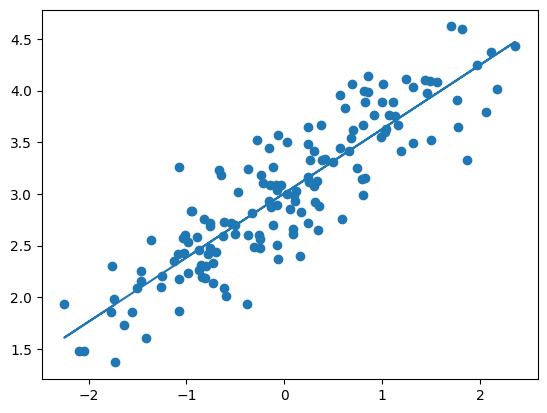

In [48]:
## plot Training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =156.470 + 17.29(X_test)

In [49]:
## Prediction for test data
y_pred=regression.predict(X_test)

In [50]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [51]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

0.09122322472141597
0.2426632743741605
0.3020318273318492


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [52]:
from sklearn.metrics import r2_score

In [53]:
score=r2_score(y_test,y_pred)
print(score)

0.7774721122516276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [54]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7728361145902032

### OLS Linear Regression


# Run this in a Jupyter notebook cell or terminal
`!pip install statsmodels`

In [55]:
## OLS Linear Regression
import statsmodels.api as sm

In [56]:
model=sm.OLS(y_train,X_train).fit()

In [57]:
prediction=model.predict(X_test)
print(prediction)

[-0.21961221  0.13447821  0.1973007  -0.60796943  0.52283544  0.76270314
  0.16303389 -0.45376877  0.17445616  0.48856862 -1.08770483 -0.64794738
  0.68274724 -0.24245675  0.47143522  0.04310004 -0.67079193  0.20301184
 -0.81928145  0.31152342 -0.54514694 -0.09967836  0.31723455 -0.12823403
  0.33436796 -0.80214805 -1.57315137 -0.28814583  0.18016729 -0.67079193
  0.73985859 -0.042567    0.6770361  -0.02543359 -0.40807968  0.34579023
 -0.5223024   0.07165572  1.16819377 -0.042567    0.09450026  0.11163367
  0.9169038  -0.27672356 -1.0819937  -0.04827813  0.07736685  0.26583433
 -1.23619436  0.34007909]


In [58]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                package   R-squared (uncentered):                   0.040
Model:                            OLS   Adj. R-squared (uncentered):              0.034
Method:                 Least Squares   F-statistic:                              6.279
Date:                Mon, 23 Feb 2026   Prob (F-statistic):                      0.0133
Time:                        13:02:05   Log-Likelihood:                         -378.87
No. Observations:                 150   AIC:                                      759.7
Df Residuals:                     149   BIC:                                      762.7
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [59]:
## Prediction For new data
regression.predict(scaler.transform([[72]]))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([40.1202819])